In [1]:
from google.colab import files
uploaded = files.upload()

Saving images.zip to images.zip


In [2]:
import zipfile

with zipfile.ZipFile('images.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

print("Extracted ✅")

Extracted ✅


In [3]:
data_dir = 'data/data'

In [4]:
import tensorflow as tf

img_size = (224,224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

print("Classes:", train_ds.class_names)

Found 7553 files belonging to 2 classes.
Using 6043 files for training.
Found 7553 files belonging to 2 classes.
Using 1510 files for validation.
Classes: ['with_mask', 'without_mask']


In [5]:
from tensorflow.keras import layers

# Data Augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# MobileNet preprocessing
preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input

train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y))

In [6]:
from tensorflow.keras import models

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [8]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.9224 - loss: 0.1920
Epoch 1: val_accuracy improved from None to 0.99603, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
189/189 ━━━━━━━━━━━━━━━━━━━━ 29s 103ms/step - accuracy: 0.9609 - loss: 0.1089 - val_accuracy: 0.9960 - val_loss: 0.0147
Epoch 2/10
188/189 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9822 - loss: 0.0539
Epoch 2: val_accuracy did not improve from 0.99603
189/189 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.9808 - loss: 0.0580 - val_accuracy: 0.9947 - val_loss: 0.0162
Epoch 3/10
188/189 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.9799 - loss: 0.0561
Epoch 3: val_accuracy did not improve from 0.99603
189/189 ━━━━━━━━━━━━━━━━━━━━ 15s 82ms/step - accuracy: 0.9830 - loss: 0.0480 - val_accuracy: 0.9947 - val_loss: 0.0178
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9833 - loss: 0.0481
Epoch 4: val_accuracy did not improve from 0.99603
189/189 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.9821 - loss: 0.0476 - val_accuracy: 0.9954 - val_loss: 0.0162


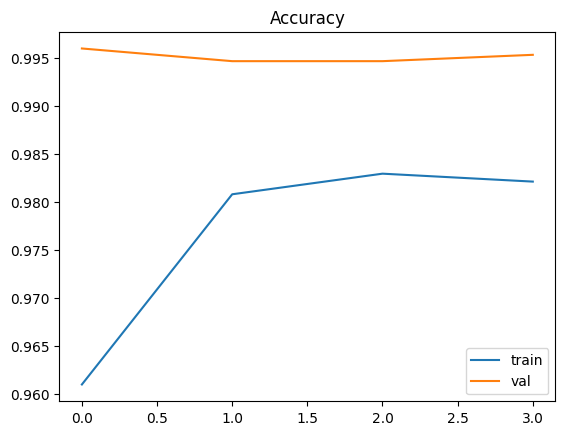

In [9]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

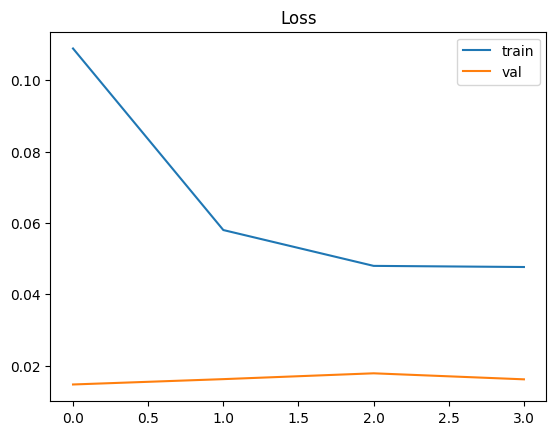

In [10]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

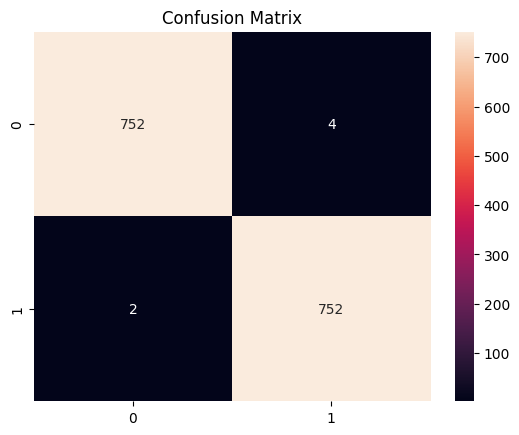

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       756
           1       0.99      1.00      1.00       754

    accuracy                           1.00      1510
   macro avg       1.00      1.00      1.00      1510
weighted avg       1.00      1.00      1.00      1510



In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred))

In [13]:
from google.colab import files
uploaded = files.upload()

Saving with_mask_26.jpg to with_mask_26.jpg


In [14]:
import os
os.listdir()

['.config',
 'with_mask_26.jpg',
 'images.zip',
 'best_model.h5',
 'data',
 'sample_data']

In [15]:
img_path = 'with_mask_26.jpg'

In [16]:
from tensorflow.keras.preprocessing import image
import numpy as np

img_path = 'with_mask_26.jpg'

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("NO MASK ❌")
else:
    print("MASK 😷")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
MASK 😷


In [17]:
val_loss, val_acc = model.evaluate(val_ds)
print("Validation Accuracy:", val_acc)

48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.9960 - loss: 0.0147
Validation Accuracy: 0.9960265159606934
